# USD Strength & Inflation Transmission — Emerging Africa (2006–2023)

## Key Finding
Nigeria shows the strongest and most immediate USD pass-through to inflation 
(r=0.68 at lag 0), consistent with high import dependency and limited FX buffers. 
Ghana shows a similar but weaker pattern. Kenya and South Africa show negative 
correlations — USD strength coincides with lower inflation, likely reflecting 
commodity export revenue offsetting import cost pressures. Egypt sits in between, 
with moderate immediate pass-through that fades within 2 years.

## Structural Interpretation
The Nigeria/Ghana vs Kenya/South Africa divergence maps cleanly onto 
import-dependent vs export-commodity economies — a structural difference 
that monetary policy alone cannot address.

## Data Sources
- World Bank: Inflation CPI (FP.CPI.TOTL.ZG), FX rate (PA.NUS.FCRF)
- FRED: DXY Broad USD Index (DTWEXBGS), Federal Funds Rate (FEDFUNDS)
- Period: 2006–2023 (DXY availability constraint)

In [1]:
import sys
sys.path.append('../../../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf
from utils.data_fetcher import fetch_wb, fetch_fred, save_data
import os

print("All imports successful")

All imports successful


In [2]:
COUNTRIES = ['NGA', 'GHA', 'KEN', 'ZAF', 'EGY']

wb_df = fetch_wb(
    {'inflation': 'FP.CPI.TOTL.ZG', 'fx_lcu_usd': 'PA.NUS.FCRF'},
    COUNTRIES, 2000, 2024
)

print(wb_df.shape)
print(wb_df.head(10))

(125, 4)
  country  year  inflation  fx_lcu_usd
0     EGY  2000   2.683805    3.472050
1     EGY  2001   2.269757    3.973000
2     EGY  2002   2.737239    4.499667
3     EGY  2003   4.507776    5.850875
4     EGY  2004  11.270619    6.196242
5     EGY  2005   4.869397    5.778833
6     EGY  2006   7.644526    5.733167
7     EGY  2007   9.318969    5.635433
8     EGY  2008  18.316832    5.432500
9     EGY  2009  11.763495    5.544553


In [3]:
fred_df = fetch_fred(
    {'dxy': 'DTWEXBGS', 'fed_rate': 'FEDFUNDS'},
    start='2000-01-01'
)

# Annualise to match World Bank yearly data
fred_annual = fred_df.resample('YE').mean()
fred_annual.index = fred_annual.index.year
fred_annual = fred_annual.reset_index().rename(columns={'index': 'year'})

print(fred_annual.shape)
print(fred_annual.head(10))

ValueError: You need to set a valid API key. You can set it in 3 ways:
pass the string with api_key, or set api_key_file to a
file with the api key in the first line, or set the
environment variable 'FRED_API_KEY' to the value of your
api key. You can sign up for a free api key on the Fred
website at http://research.stlouisfed.org/fred2/

In [4]:
from dotenv import load_dotenv
import os

load_dotenv()
print(os.getenv('FRED_API_KEY'))

None


In [7]:
os.environ['FRED_API_KEY'] = 'fd48e337814710236a4eb138a4f168ad'
print(os.getenv('FRED_API_KEY'))

fd48e337814710236a4eb138a4f168ad


In [8]:
fred_df = fetch_fred(
    {'dxy': 'DTWEXBGS', 'fed_rate': 'FEDFUNDS'},
    start='2000-01-01'
)

fred_annual = fred_df.resample('YE').mean()
fred_annual.index = fred_annual.index.year
fred_annual = fred_annual.reset_index().rename(columns={'index': 'year'})

print(fred_annual.shape)
print(fred_annual.head(10))

(27, 3)
   year        dxy  fed_rate
0  2000        NaN  6.235833
1  2001        NaN  3.887500
2  2002        NaN  1.666667
3  2003        NaN  1.127500
4  2004        NaN  1.349167
5  2005        NaN  3.213333
6  2006  98.600466  4.964167
7  2007  93.809965  5.019167
8  2008  90.880132  1.927500
9  2009  96.750927  0.160000


In [9]:
merged = wb_df.merge(fred_annual, on='year', how='left').dropna()

print(merged.shape)
print(merged.head())

(95, 6)
   country  year  inflation  fx_lcu_usd        dxy  fed_rate
6      EGY  2006   7.644526    5.733167  98.600466  4.964167
7      EGY  2007   9.318969    5.635433  93.809965  5.019167
8      EGY  2008  18.316832    5.432500  90.880132  1.927500
9      EGY  2009  11.763495    5.544553  96.750927  0.160000
10     EGY  2010  11.265188    5.621943  93.054137  0.175000


In [10]:
results = []

for country in COUNTRIES:
    cdf = merged[merged['country'] == country].sort_values('year')
    if len(cdf) < 10:
        continue

    x = (cdf['dxy'] - cdf['dxy'].mean()) / cdf['dxy'].std()
    y = (cdf['inflation'] - cdf['inflation'].mean()) / cdf['inflation'].std()

    correlations = ccf(x, y, nlags=5, alpha=None)

    for lag, corr in enumerate(correlations[:6]):
        results.append({'country': country, 'lag_years': lag, 'correlation': corr})

lag_df = pd.DataFrame(results)
print(lag_df)

   country  lag_years  correlation
0      NGA          0     0.683878
1      NGA          1     0.432097
2      NGA          2     0.225663
3      NGA          3     0.134649
4      NGA          4     0.065166
5      GHA          0     0.439497
6      GHA          1     0.392421
7      GHA          2     0.091362
8      GHA          3    -0.183579
9      GHA          4    -0.211861
10     KEN          0    -0.495374
11     KEN          1    -0.415691
12     KEN          2    -0.568726
13     KEN          3    -0.646940
14     KEN          4    -0.594226
15     ZAF          0    -0.287500
16     ZAF          1    -0.132289
17     ZAF          2    -0.238098
18     ZAF          3    -0.453123
19     ZAF          4    -0.433763
20     EGY          0     0.429347
21     EGY          1     0.302849
22     EGY          2     0.035830
23     EGY          3    -0.084478
24     EGY          4    -0.075190


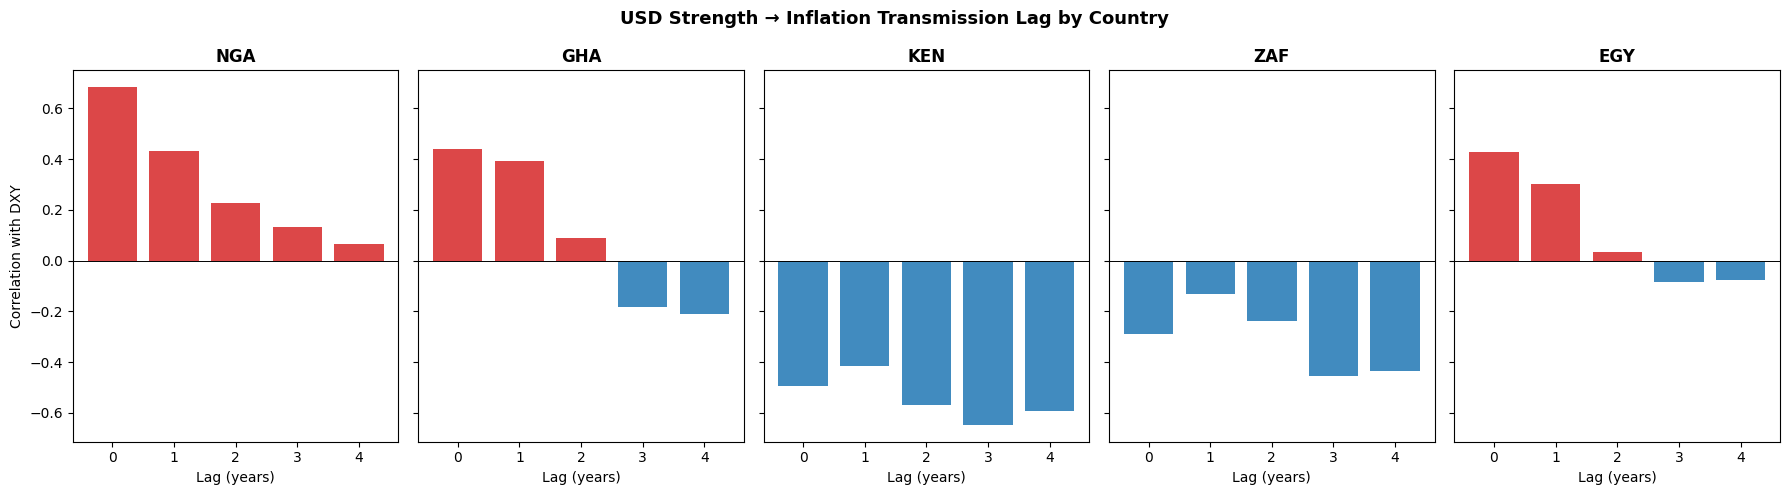

In [11]:
fig, axes = plt.subplots(1, len(COUNTRIES), figsize=(18, 5), sharey=True)

for i, country in enumerate(COUNTRIES):
    cdf = lag_df[lag_df['country'] == country]
    ax = axes[i]
    ax.bar(cdf['lag_years'], cdf['correlation'],
           color=['#d62728' if c > 0 else '#1f77b4' for c in cdf['correlation']],
           alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_title(country, fontweight='bold')
    ax.set_xlabel('Lag (years)')
    ax.set_xticks(cdf['lag_years'])

axes[0].set_ylabel('Correlation with DXY')
fig.suptitle('USD Strength → Inflation Transmission Lag by Country',
             fontsize=13, fontweight='bold')

plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/lag_correlations.png', dpi=150, bbox_inches='tight')
plt.show()